In [1]:
import pandas as pd
import warnings

from dmm.config_options import Conf
from sensitivity import compute_sensitivities
from training_configuration import SPLITS

warnings.filterwarnings("ignore")


/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotat

In [2]:
conf = Conf(
    model="EGFR_MAPK__logobs",  # base model
    data="dream_cytof",
    n_hidden=8,
    depth=0,
    dropout_rate=0.1,
    l1reg_inflater_output=1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output=0,
    recon_loss=1e-4,
    n_epoch=500,
    multiheaded=False,
)

results_params_df, results_latent_df = compute_sensitivities(
    conf=conf,
    context_features=[("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")],
    splits=[split for split in SPLITS if split != "all"],
    latent_sensitivities={"cytof_init": True, "multimodal": True},
    n_jobs=10,
    multiheaded_multimodal=True,
)

results_params_df.to_csv(
    "sensitivity_analysis_params_cytof_init_multimodal_base_p38_nhidden8.csv",
    index=False
)

results_latent_df.to_csv(
    "sensitivity_analysis_latent_cytof_init_multimodal_base_p38_nhidden8.csv",
    index=False
)

context=multimodal, split=MCF7, job=9, latents: 100%|██████████| 8/8 [00:06<00:00,  1.23it/s]
context=multimodal, split=UACC3199, job=0, params: 100%|██████████| 44/44 [00:54<00:00,  1.24s/it]
context=multimodal, split=UACC3199, job=0, latents: 100%|██████████| 8/8 [00:07<00:00,  1.04it/s]
context=multimodal, split=UACC3199, job=1, params: 100%|██████████| 44/44 [00:53<00:00,  1.20s/it]
context=multimodal, split=UACC3199, job=1, latents: 100%|██████████| 8/8 [00:05<00:00,  1.51it/s]
context=multimodal, split=UACC3199, job=2, params: 100%|██████████| 44/44 [00:48<00:00,  1.11s/it]
context=multimodal, split=UACC3199, job=2, latents: 100%|██████████| 8/8 [00:07<00:00,  1.13it/s]
context=multimodal, split=UACC3199, job=3, params: 100%|██████████| 44/44 [00:54<00:00,  1.25s/it]
context=multimodal, split=UACC3199, job=3, latents: 100%|██████████| 8/8 [00:05<00:00,  1.49it/s]
context=multimodal, split=UACC3199, job=4, params: 100%|██████████| 44/44 [00:53<00:00,  1.21s/it]
context=multimodal,

## Reload from here directly

In [5]:
results_params_df = pd.read_csv("sensitivity_analysis_params_cytof_init_multimodal_base_p38_nhidden8.csv")
results_latent_df = pd.read_csv("sensitivity_analysis_latent_cytof_init_multimodal_base_p38_nhidden8.csv")

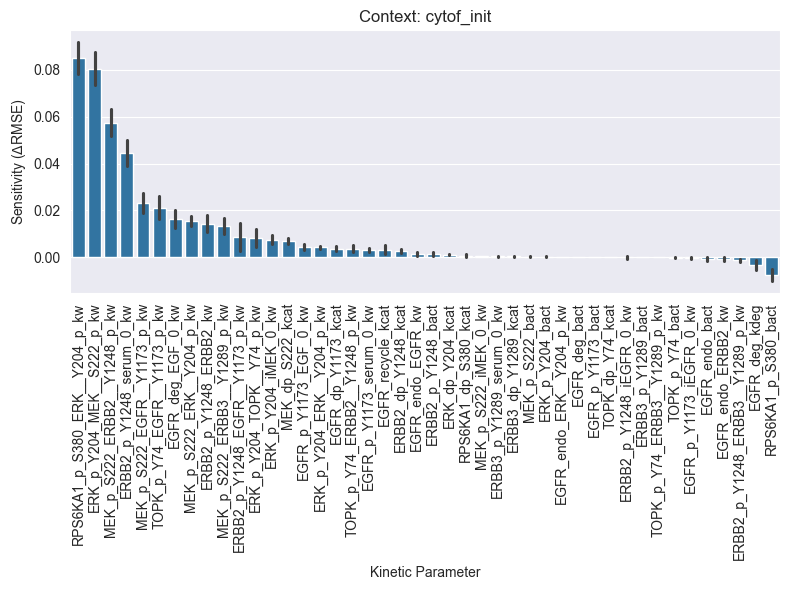

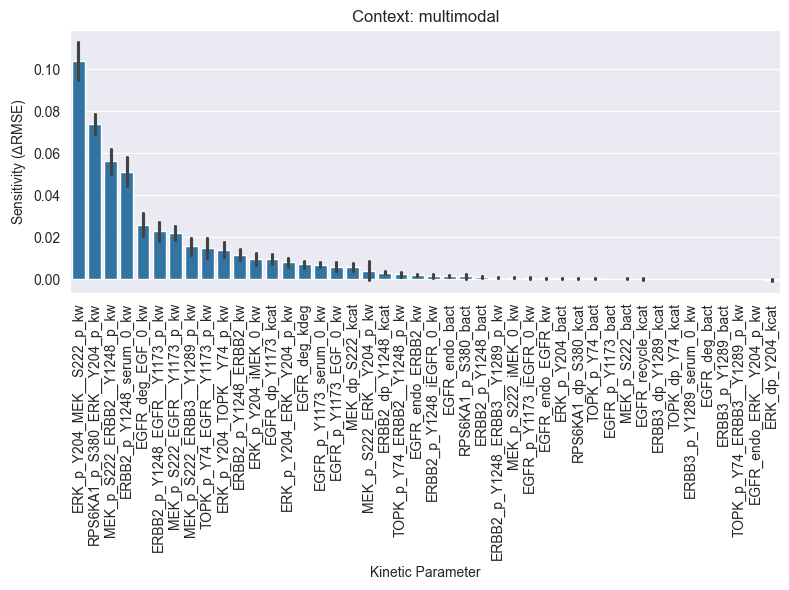

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


for context, _ in [("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")]:
    # filter to multimodal context
    df = results_params_df[(results_params_df.context == context)]

    # compute mean rmse_diff per param
    order = (
        df.groupby("param")["rmse_diff_zeroed"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    plt.figure(figsize=(8, 6))
    # plot with that order
    sns.barplot(
        data=df,
        x="param",
        y="rmse_diff_zeroed",
        order=order,
        errorbar="se"
    )

    plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
    plt.xlabel("Kinetic Parameter")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()

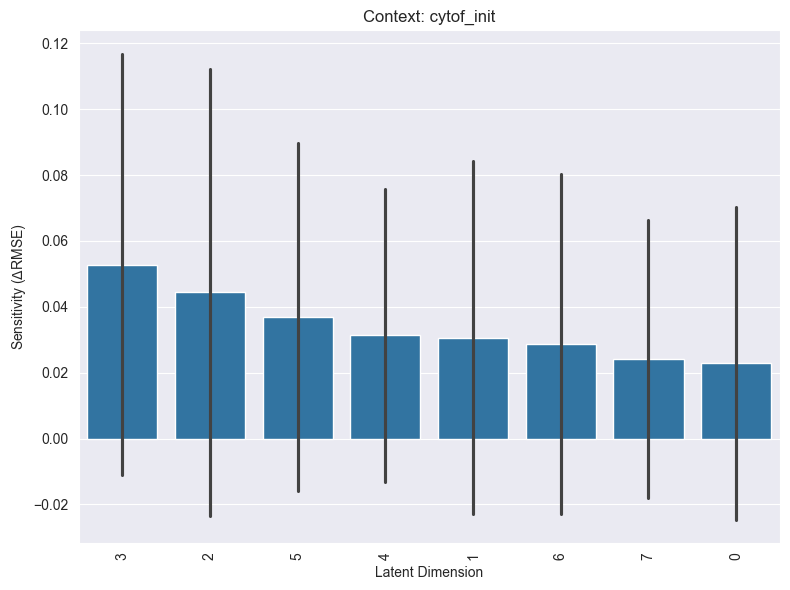

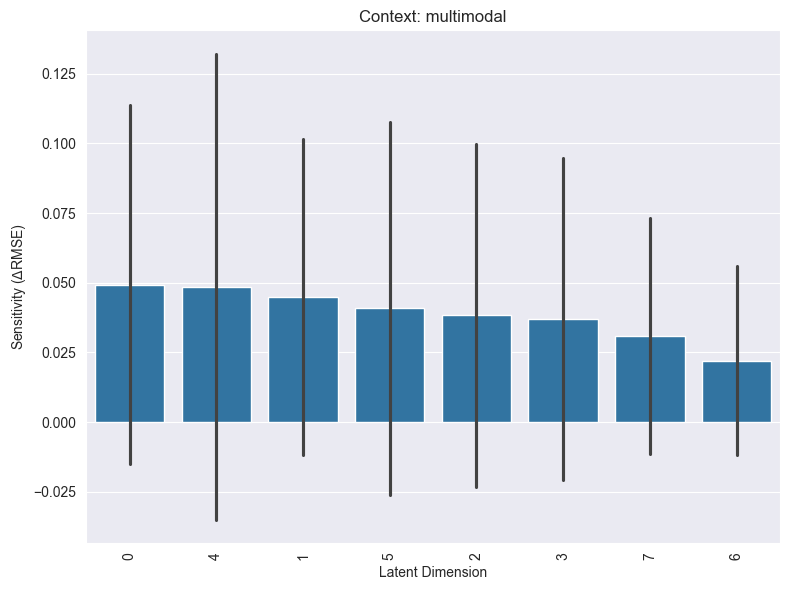

In [7]:
for context, _ in [("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")]:
    # filter to multimodal context
    df = results_latent_df[(results_latent_df.context == context)]

    # compute mean rmse_diff per param
    order = (
        df.groupby("latent_dimension")["rmse_diff"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    plt.figure(figsize=(8, 6))
    # plot with that order
    sns.barplot(
        data=df,
        x="latent_dimension",
        y="rmse_diff",
        order=order,
        errorbar="sd"
    )

    plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
    plt.xlabel("Latent Dimension")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()

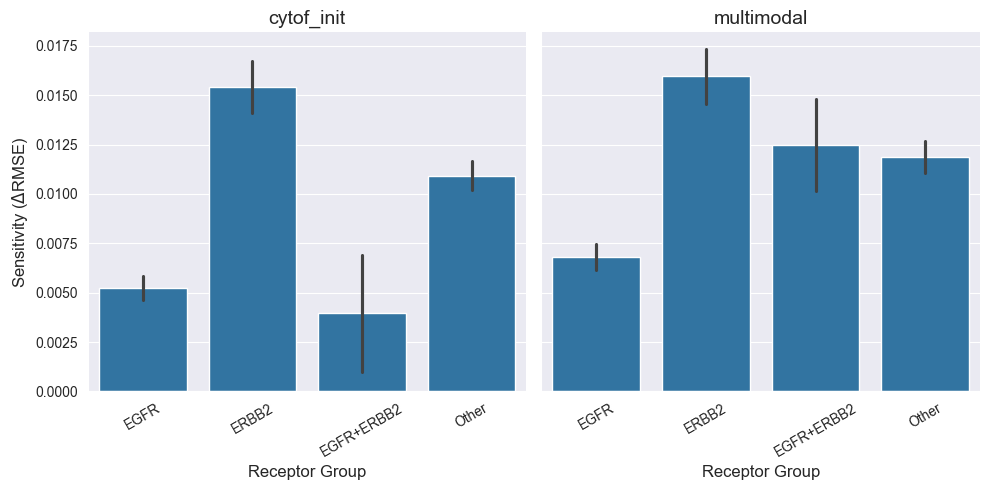

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: pretty names for contexts
context_labels = {
    "cytof_init": "cytof_init",
    "multimodal": "multimodal"
}

# Create FacetGrid
g = sns.FacetGrid(
    results_params_df,
    col="context",
    col_order=["cytof_init", "multimodal"],
    height=5,
    sharey=True,
)

# Plot barplots
g.map_dataframe(
    sns.barplot,
    x="receptor_group",
    y="rmse_diff_zeroed",
    order=["EGFR", "ERBB2", "EGFR+ERBB2", "Other"],
    errorbar="se"   # optional if you have uncertainty
)

# Set axis labels
g.set_axis_labels("Receptor Group", r"Sensitivity ($\Delta$RMSE)", fontsize=12)

# Improve facet titles
for ax, context in zip(g.axes.flat, ["cytof_init", "multimodal"]):
    ax.set_title(context_labels[context], fontsize=14)

# Optional: rotate x labels for readability
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()